# Conv1D Hybrid Autoencoder — Búsqueda de Hiperparámetros con Optuna
## Dataset: SWaT A12 (Marzo 2026)

### Diferencias respecto al pipeline de SWaT A7 (2020)

| Aspecto | A7 2020 | A12 2026 |
|---------|---------|----------|
| Archivos | 4 CSVs de días distintos | **1 único CSV** (8h de operación) |
| Etiquetas | Sin etiquetas (todo normal) | attack_label ya incluido |
| Entrenamiento | Todos los datos | **Solo filas con attack_label = 0** |
| Columnas extra | No | Alarms, P_STATE, Speed |
| Valores no numéricos | No | "Bad Input" en Status y State |

### Estrategia de preprocesamiento

1. **Filtrar filas normales** antes de cualquier split o escalado
2. **Eliminar columnas constantes** automáticamente
3. **"Bad Input"** → convertir a NaN → rellenar con la moda del train
4. **Alarms** → excluidas (mayoría constantes o solo "Bad Input")
5. **Split temporal 60/20/20** sobre el subconjunto normal
6. **Validación externa** con las filas de ataque → se hará en notebook posterior

El modelo `HybridConv1DAutoencoder` es idéntico al de A7: rama Conv1D para
continuas + rama MLP para discretas + fusión. Optuna busca los mejores
hiperparámetros sobre la val_loss en datos normales.


## 0. Imports

In [1]:
import os
import random
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

from sklearn.preprocessing import StandardScaler


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 1. Rutas del proyecto

In [3]:
current_dir = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / "data").exists() else current_dir.parent

RAW_CSV   = PROJECT_ROOT / "data" / "clean" / "SWaT.A12_OTDataset_Mar_26" / "11-Mar-2026_0900_1700_labeled.csv"
SAVE_DIR  = PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_a12"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT.resolve())
print("CSV exists  :", RAW_CSV.exists())
print("Save dir    :", SAVE_DIR)


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
CSV exists  : True
Save dir    : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12


## 2. Carga del CSV y separación normal / ataque

Se separan las filas de operación normal **antes** de cualquier preprocesamiento.
Las filas de ataque se conservan aparte para la validación externa supervisada.


In [4]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw["t_stamp"] = pd.to_datetime(df_raw["t_stamp"], errors="coerce")
df_raw = df_raw.sort_values("t_stamp").reset_index(drop=True)
df_raw["attack_label"] = pd.to_numeric(df_raw["attack_label"], errors="coerce").fillna(0).astype(int)

print(f"Total filas: {len(df_raw)}")
print(f"Período: {df_raw['t_stamp'].min()} → {df_raw['t_stamp'].max()}")
print(f"Ataque (label=1): {(df_raw['attack_label']==1).sum()} filas  ({100*(df_raw['attack_label']==1).mean():.1f}%)")
print(f"Normal (label=0): {(df_raw['attack_label']==0).sum()} filas  ({100*(df_raw['attack_label']==0).mean():.1f}%)")

# Separar — NO mezclar; solo normal para entrenamiento
META_COLS = ["attack_label","attack_id","attack_name","attack_targets",
             "attack_start_time","attack_end_time"]

df_normal = df_raw[df_raw["attack_label"] == 0].copy().reset_index(drop=True)
df_attack = df_raw[df_raw["attack_label"] == 1].copy().reset_index(drop=True)

print(f"\ndf_normal: {df_normal.shape} → se usará para entrenamiento/validación interna")
print(f"df_attack: {df_attack.shape}  → reservado para validación externa supervisada")


Total filas: 28860
Período: 2026-03-11 09:00:00 → 2026-03-11 17:00:59
Ataque (label=1): 3120 filas  (10.8%)
Normal (label=0): 25740 filas  (89.2%)

df_normal: (25740, 93) → se usará para entrenamiento/validación interna
df_attack: (3120, 93)  → reservado para validación externa supervisada


## 3. Clasificación y selección de columnas

### Columnas del dataset A12

| Tipo | Sufijo / patrón | Tratamiento |
|------|----------------|-------------|
| Continuas | `.Pv`, `P501.Speed` | StandardScaler |
| Discretas | `.Status`, `P*_STATE` | Moda para NaN; normalizar por max |
| Alarmas | `.Alarm` | **Excluidas** — mayoría constantes o solo "Bad Input" |
| Meta | `attack_*`, `t_stamp` | Ignoradas en entrenamiento |

`Bad Input` en columnas numéricas → se convierte a NaN y se imputa con moda del train.


In [5]:
# Columnas de sensores y actuadores
all_sensor_cols = [c for c in df_raw.columns if c not in ["t_stamp"] + META_COLS]

pv_cols     = [c for c in all_sensor_cols if c.endswith(".Pv")]
status_cols = [c for c in all_sensor_cols if c.endswith(".Status")]
state_cols  = [c for c in all_sensor_cols if c.endswith("_STATE")]
alarm_cols  = [c for c in all_sensor_cols if c.endswith(".Alarm")]
speed_cols  = [c for c in all_sensor_cols if c.endswith(".Speed")]

print(f"Cols .Pv      : {len(pv_cols)}")
print(f"Cols .Status  : {len(status_cols)}")
print(f"Cols _STATE   : {len(state_cols)}")
print(f"Cols .Alarm   : {len(alarm_cols)} → excluidas")
print(f"Cols .Speed   : {speed_cols}")


Cols .Pv      : 31
Cols .Status  : 32
Cols _STATE   : 6
Cols .Alarm   : 15 → excluidas
Cols .Speed   : ['P501.Speed', 'P502.Speed']


In [6]:
# Convertir 'Bad Input' a NaN en todo el dataframe (sobre columnas sensor)
sensor_candidate_cols = pv_cols + status_cols + state_cols + speed_cols
df_all = df_raw[["t_stamp", "attack_label"] + sensor_candidate_cols].copy()

for col in sensor_candidate_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace("Bad Input", np.nan), errors="coerce")

# Detectar columnas constantes en los datos NORMALES
df_norm_check = df_all[df_all["attack_label"] == 0][sensor_candidate_cols]
n_unique_per_col = df_norm_check.nunique(dropna=True)
constant_cols = n_unique_per_col[n_unique_per_col <= 1].index.tolist()

print("Columnas constantes (serán eliminadas):")
for c in constant_cols:
    unique_vals = df_norm_check[c].dropna().unique().tolist()
    print(f"  {c:25s} → {unique_vals}")

print(f"\nTotal constantes: {len(constant_cols)}")


Columnas constantes (serán eliminadas):
  AIT401.Pv                 → [0.0]
  P207.Status               → [1.0]
  P208.Status               → [1.0]
  P302.Status               → [1]
  P402.Status               → [1]
  P404.Status               → [1]
  P502.Status               → [1]
  P603.Status               → [1]
  P502.Speed                → [0.0]

Total constantes: 9


In [7]:
# Columnas finales
pv_cols_final     = [c for c in pv_cols     if c not in constant_cols]
status_cols_final = [c for c in status_cols if c not in constant_cols]
state_cols_final  = [c for c in state_cols  if c not in constant_cols]
speed_cols_final  = [c for c in speed_cols  if c not in constant_cols]

# Continuas: .Pv + Speed no constantes
continuous_cols = pv_cols_final + speed_cols_final

# Discretas: .Status + _STATE no constantes
discrete_cols = status_cols_final + state_cols_final

feature_cols = continuous_cols + discrete_cols

print(f"Continuas : {len(continuous_cols)}")
print(f"  .Pv     : {pv_cols_final}")
print(f"  .Speed  : {speed_cols_final}")
print(f"\nDiscretas : {len(discrete_cols)}")
print(f"  .Status : {status_cols_final}")
print(f"  _STATE  : {state_cols_final}")
print(f"\nTotal feature_cols: {len(feature_cols)}")


Continuas : 31
  .Pv     : ['LIT101.Pv', 'FIT101.Pv', 'FIT201.Pv', 'AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT301.Pv', 'AIT302.Pv', 'AIT303.Pv', 'LIT301.Pv', 'FIT301.Pv', 'DPIT301.Pv', 'LIT401.Pv', 'FIT401.Pv', 'AIT402.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv', 'LIT601.Pv', 'LIT602.Pv', 'FIT601.Pv', 'FIT602.Pv']
  .Speed  : ['P501.Speed']

Discretas : 31
  .Status : ['MV101.Status', 'P101.Status', 'P102.Status', 'MV201.Status', 'P201.Status', 'P202.Status', 'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status', 'MV301.Status', 'MV302.Status', 'MV303.Status', 'MV304.Status', 'P301.Status', 'P401.Status', 'P403.Status', 'UV401.Status', 'P501.Status', 'MV501.Status', 'MV502.Status', 'MV503.Status', 'MV504.Status', 'P601.Status', 'P602.Status']
  _STATE  : ['P1_STATE', 'P2_STATE', 'P3_STATE', 'P4_STATE', 'P5_STATE', 'P6_STATE']

Total feature_cols: 62


## 4. Warmup y split temporal

Se eliminan los primeros 120 segundos (warmup del sistema).
Luego se hace un split **temporal estricto** 60/20/20 sobre las filas normales.
No se mezclan filas de distintos segmentos temporales.


In [8]:
WARMUP_SECONDS = 120

df_work = df_all[df_all["attack_label"] == 0][["t_stamp"] + feature_cols].copy()
df_work = df_work[df_work["t_stamp"] >= df_work["t_stamp"].min() + pd.Timedelta(seconds=WARMUP_SECONDS)]
df_work = df_work.reset_index(drop=True)

print(f"Filas normales tras warmup: {len(df_work)}")
print(f"Período normal: {df_work['t_stamp'].min()} → {df_work['t_stamp'].max()}")

# Split temporal
n = len(df_work)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

df_train = df_work.iloc[:train_end].copy().reset_index(drop=True)
df_val   = df_work.iloc[train_end:val_end].copy().reset_index(drop=True)
df_test  = df_work.iloc[val_end:].copy().reset_index(drop=True)

print(f"\nSplit (solo filas normales post-warmup):")
print(f"  Train : {len(df_train):6,} filas  ({len(df_train)/n*100:.0f}%)")
print(f"  Val   : {len(df_val):6,} filas  ({len(df_val)/n*100:.0f}%)")
print(f"  Test  : {len(df_test):6,} filas  ({len(df_test)/n*100:.0f}%)")


Filas normales tras warmup: 25620
Período normal: 2026-03-11 09:02:00 → 2026-03-11 17:00:59

Split (solo filas normales post-warmup):
  Train : 15,372 filas  (60%)
  Val   :  5,124 filas  (20%)
  Test  :  5,124 filas  (20%)


## 5. Imputación de Bad Input y escalado

`Bad Input` ya fue convertido a NaN en la sección 3.
Ahora se imputa con la **moda del train** y se escala con StandardScaler.


In [9]:
# Imputar NaN con moda del TRAIN (en continuas y discretas)
modes_train = df_train[feature_cols].mode().iloc[0]

df_train[feature_cols] = df_train[feature_cols].fillna(modes_train)
df_val[feature_cols]   = df_val[feature_cols].fillna(modes_train)
df_test[feature_cols]  = df_test[feature_cols].fillna(modes_train)

# Verificar
nan_after = df_train[feature_cols].isna().sum().sum()
print(f"NaN tras imputación en train: {nan_after}")

# StandardScaler solo en continuas — ajuste SOLO en train
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)

def apply_scaling(df):
    df = df.copy()
    df[continuous_cols] = scaler_cont.transform(df[continuous_cols].values)
    return df

df_train_sc = apply_scaling(df_train)
df_val_sc   = apply_scaling(df_val)
df_test_sc  = apply_scaling(df_test)

print("Escalado aplicado.")
print(f"  Train cont rango: [{df_train_sc[continuous_cols].values.min():.2f}, "
      f"{df_train_sc[continuous_cols].values.max():.2f}]")


NaN tras imputación en train: 0
Escalado aplicado.
  Train cont rango: [-6.66, 71.58]


In [10]:
# Normalizar discretas por su máximo en train (igual que A7)
disc_max = df_train[discrete_cols].max()
disc_max = disc_max.replace(0, 1)  # evitar división por cero

df_train_sc[discrete_cols] = df_train[discrete_cols] / disc_max
df_val_sc[discrete_cols]   = df_val[discrete_cols]   / disc_max
df_test_sc[discrete_cols]  = df_test[discrete_cols]  / disc_max

# Clip por si hay valores > 1 en val/test
df_val_sc[discrete_cols]  = df_val_sc[discrete_cols].clip(0, 2)
df_test_sc[discrete_cols] = df_test_sc[discrete_cols].clip(0, 2)

print(f"disc_max:\n{disc_max.to_string()}")


disc_max:
MV101.Status     2.0
P101.Status      2.0
P102.Status      1.0
MV201.Status     2.0
P201.Status      2.0
P202.Status      1.0
P203.Status      2.0
P204.Status      1.0
P205.Status      2.0
P206.Status      1.0
MV301.Status     1.0
MV302.Status     2.0
MV303.Status     1.0
MV304.Status     2.0
P301.Status      2.0
P401.Status      2.0
P403.Status      2.0
UV401.Status     2.0
P501.Status      2.0
MV501.Status     2.0
MV502.Status     2.0
MV503.Status     2.0
MV504.Status     2.0
P601.Status      2.0
P602.Status      1.0
P1_STATE         3.0
P2_STATE         2.0
P3_STATE        99.0
P4_STATE         4.0
P5_STATE        12.0
P6_STATE         2.0


In [11]:
# Guardar scaler y disc_max — serán reutilizados en todos los notebooks posteriores
joblib.dump(scaler_cont, SAVE_DIR / "scaler_cont.pkl")
joblib.dump(disc_max.to_dict(), SAVE_DIR / "disc_max_dict.pkl")

print("✅ scaler_cont.pkl y disc_max_dict.pkl guardados en:", SAVE_DIR)


✅ scaler_cont.pkl y disc_max_dict.pkl guardados en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12


## 6. Construcción de ventanas

Las ventanas se construyen **por separado** para continuas y discretas.
Las continuas van al branch Conv1D en formato `(N, features, timesteps)`.
Las discretas se resumen por ventana en estadísticas escalares (mode, transitions, etc.)
y van al branch MLP.


In [12]:
def create_windows(arr, window_size, stride):
    """Ventanas deslizantes. arr: (T, features) → (N, window_size, features)"""

    windows = []
    for i in range(0, len(arr) - window_size + 1, stride):
        windows.append(arr[i:i + window_size])
    return np.array(windows, dtype=np.float32) if windows else np.empty((0, window_size, arr.shape[1]), dtype=np.float32)


def summarize_discrete_windows(disc_windows, discrete_cols):
    """Genera features de resumen por ventana para las discretas.
    
    Por cada variable discreta extrae: moda, nº transiciones, dominancia, nº únicos.
    Esto comprime (N, W, D) → (N, D*4) para el branch MLP.
    """
    rows = []
    for w in disc_windows:            # w: (window_size, n_disc)
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            series = pd.Series(v)
            feats[f"{col}__mode"]        = series.mode().iloc[0] if len(series.mode()) > 0 else 0.0
            feats[f"{col}__transitions"] = float(np.sum(v[1:] != v[:-1]))
            feats[f"{col}__nunique"]     = float(len(np.unique(v)))
            feats[f"{col}__dominance"]   = float(series.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)


def build_windows_from_df(df_scaled, continuous_cols, discrete_cols, window_size, stride):
    """Construye ventanas de continuas y discretas desde un DataFrame escalado."""

    cont_arr = df_scaled[continuous_cols].values.astype(np.float32)
    disc_arr = df_scaled[discrete_cols].values.astype(np.float32)

    cont_w = create_windows(cont_arr, window_size, stride)  # (N, W, C)
    disc_w = create_windows(disc_arr, window_size, stride)  # (N, W, D)

    if len(cont_w) == 0:
        return None, None, None, None

    X_cont = np.transpose(cont_w, (0, 2, 1))  # → (N, C, W) para Conv1D
    X_disc = summarize_discrete_windows(disc_w, discrete_cols).values.astype(np.float32)

    return X_cont, X_disc, cont_w, disc_w


print("Funciones de ventanas definidas.")


Funciones de ventanas definidas.


In [13]:
# Test rápido con hiperparámetros por defecto para verificar shapes
_X_cont, _X_disc, _, _ = build_windows_from_df(
    df_train_sc, continuous_cols, discrete_cols, window_size=60, stride=5
)
print("Ventanas train (window=60, stride=5):")
print(f"  X_cont: {_X_cont.shape}  (N, n_cont, timesteps)")
print(f"  X_disc: {_X_disc.shape}  (N, n_disc_features)")
print(f"  Ratio cont/disc features: {_X_cont.shape[1]}/{_X_disc.shape[1]}")
del _X_cont, _X_disc


Ventanas train (window=60, stride=5):
  X_cont: (3063, 31, 60)  (N, n_cont, timesteps)
  X_disc: (3063, 124)  (N, n_disc_features)
  Ratio cont/disc features: 31/124


## 7. Modelo HybridConv1DAutoencoder

Idéntico al de A7 — dos ramas independientes que se fusionan:
- **Rama Conv1D** para series temporales continuas
- **Rama MLP** para las características resumidas de variables discretas

El encoder comprime ambas representaciones, las fusiona con una capa densa,
y el decoder las reconstruye por separado. La loss final es la suma ponderada.


In [14]:
class HybridConv1DAutoencoder(nn.Module):
    """Autoencoder híbrido Conv1D (continuas) + MLP (discretas).

    - Rama continua: n_conv_layers bloques Conv1D→ReLU→Dropout→MaxPool
    - Rama discreta: 2 capas lineales
    - Fusión: concatenación de ambas representaciones → capa lineal → split
    - Decoder: espejo de los encoders

    La salida son dos tensores: x_cont_hat y x_disc_hat, reconstruyendo
    las entradas de cada rama respectivamente.
    """

    def __init__(
        self,
        cont_channels, seq_len, disc_dim,
        n_conv_layers=2,
        conv_channels_1=32, conv_channels_2=16, conv_channels_3=8,
        kernel_size=3,
        disc_hidden_1=64, disc_hidden_2=32,
        fusion_hidden=128,
        dropout=0.1
    ):
        super().__init__()
        self.cont_channels = cont_channels
        self.seq_len       = seq_len
        self.disc_dim      = disc_dim
        self.n_conv_layers = n_conv_layers

        # Encoder continuas — n_conv_layers bloques dinámicos
        channels_list = [cont_channels]
        if n_conv_layers >= 1: channels_list.append(conv_channels_1)
        if n_conv_layers >= 2: channels_list.append(conv_channels_2)
        if n_conv_layers >= 3: channels_list.append(conv_channels_3)

        encoder_layers = []
        current_seq_len = seq_len
        for i in range(len(channels_list) - 1):
            encoder_layers += [
                nn.Conv1d(channels_list[i], channels_list[i+1],
                          kernel_size=kernel_size, padding=kernel_size//2),
                nn.ReLU(), nn.Dropout(dropout), nn.MaxPool1d(2)
            ]
            current_seq_len //= 2
        self.encoder_conv = nn.Sequential(*encoder_layers)
        self.reduced_len  = current_seq_len
        self.last_ch      = channels_list[-1]
        self.conv_flat    = self.last_ch * self.reduced_len

        # Encoder discretas
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden_1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden_1, disc_hidden_2), nn.ReLU()
        )

        # Fusión → bottleneck
        self.fusion = nn.Sequential(
            nn.Linear(self.conv_flat + disc_hidden_2, fusion_hidden),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fusion_hidden, self.conv_flat + disc_hidden_2)
        )

        # Decoder continuas — espejo del encoder
        rev_channels = list(reversed(channels_list))
        decoder_layers = []
        for i in range(len(rev_channels) - 1):
            decoder_layers += [
                nn.ConvTranspose1d(rev_channels[i], rev_channels[i+1],
                                   kernel_size=2, stride=2),
                nn.ReLU(), nn.Dropout(dropout)
            ]
        # Última capa sin ReLU/Dropout para salida libre
        decoder_layers.append(
            nn.Conv1d(rev_channels[-1], rev_channels[-1],
                      kernel_size=kernel_size, padding=kernel_size//2)
        )
        self.decoder_conv = nn.Sequential(*decoder_layers)

        # Decoder discretas — espejo del encoder discreto
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden_2, disc_hidden_1), nn.ReLU(),
            nn.Linear(disc_hidden_1, disc_dim)
        )

    def forward(self, x_cont, x_disc):
        # Encode
        h_conv  = self.encoder_conv(x_cont).view(x_cont.size(0), -1)
        h_disc  = self.encoder_disc(x_disc)

        # Fusión
        fused   = torch.cat([h_conv, h_disc], dim=1)
        bottleneck = self.fusion(fused)
        h_conv_d = bottleneck[:, :self.conv_flat]
        h_disc_d = bottleneck[:, self.conv_flat:]

        # Decode continuas
        h_conv_d = h_conv_d.view(x_cont.size(0), self.last_ch, self.reduced_len)
        x_cont_hat = self.decoder_conv(h_conv_d)
        # Ajustar longitud si hay diferencia por padding
        if x_cont_hat.shape[2] != self.seq_len:
            x_cont_hat = x_cont_hat[:, :, :self.seq_len]

        # Decode discretas
        x_disc_hat = self.decoder_disc(h_disc_d)

        return x_cont_hat, x_disc_hat


## 8. Función de entrenamiento para Optuna

Se entrena durante las épocas fijadas y se reporta la val_loss a cada época
para que Optuna pueda podar trials malos temprano (MedianPruner).


In [15]:
def hybrid_criterion(x_cont, x_cont_hat, x_disc, x_disc_hat, alpha=0.5):
    """Loss combinada: alpha*MSE_cont + (1-alpha)*MSE_disc."""

    loss_cont = nn.functional.mse_loss(x_cont_hat, x_cont)
    loss_disc = nn.functional.mse_loss(x_disc_hat, x_disc)
    return alpha * loss_cont + (1 - alpha) * loss_disc


def train_one_trial(model, train_loader, val_loader, optimizer, device,
                    epochs, alpha=0.5, trial=None):
    best_val = float("inf")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x_cont_b, x_disc_b in train_loader:
            x_cont_b = x_cont_b.to(device)
            x_disc_b = x_disc_b.to(device)
            optimizer.zero_grad()
            x_cont_hat, x_disc_hat = model(x_cont_b, x_disc_b)
            loss = hybrid_criterion(x_cont_b, x_cont_hat, x_disc_b, x_disc_hat, alpha)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_cont_b, x_disc_b in val_loader:
                x_cont_b = x_cont_b.to(device)
                x_disc_b = x_disc_b.to(device)
                x_cont_hat, x_disc_hat = model(x_cont_b, x_disc_b)
                val_loss += hybrid_criterion(x_cont_b, x_cont_hat, x_disc_b, x_disc_hat, alpha).item()
        val_loss /= len(val_loader)

        if trial is not None:
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        best_val = min(best_val, val_loss)

    return best_val


## 9. Función objetivo de Optuna

Se busca minimizar la `val_loss` (MSE de reconstrucción en datos normales).

**Espacio de búsqueda:**

| Parámetro | Opciones |
|-----------|----------|
| `window_size` | 30, 60, 120 |
| `stride` | 1, 5, 10 |
| `n_conv_layers` | 1, 2, 3 |
| `conv_channels_*` | 16, 32, 64 |
| `kernel_size` | 3, 5, 7 |
| `disc_hidden_*` | 32, 64, 128 |
| `fusion_hidden` | 64, 128, 256 |
| `dropout` | [0.0, 0.3] |
| `batch_size` | 32, 64, 128 |
| `lr` | [1e-4, 5e-3] log |
| `optimizer` | Adam, AdamW |
| `alpha` | [0.3, 0.7] |
| `epochs` | 20, 30, 40 |


In [16]:
def objective(trial):
    # ── Hiperparámetros de datos ─────────────────────────────────────────────
    window_size = trial.suggest_categorical("window_size", [30, 60, 120])
    stride      = trial.suggest_categorical("stride", [1, 5, 10])

    # Compatibilidad: window_size debe ser divisible por 2^n_conv_layers
    n_conv_layers = trial.suggest_categorical("n_conv_layers", [1, 2, 3])
    downsample    = 2 ** n_conv_layers
    if window_size % downsample != 0:
        raise optuna.TrialPruned()

    # ── Construir ventanas con estos hiperparámetros ─────────────────────────
    X_tr_c, X_tr_d, _, _ = build_windows_from_df(
        df_train_sc, continuous_cols, discrete_cols, window_size, stride)
    X_va_c, X_va_d, _, _ = build_windows_from_df(
        df_val_sc, continuous_cols, discrete_cols, window_size, stride)

    if X_tr_c is None or len(X_tr_c) == 0 or len(X_va_c) == 0:
        raise optuna.TrialPruned()

    # ── Hiperparámetros de arquitectura ──────────────────────────────────────
    conv_channels_1 = trial.suggest_categorical("conv_channels_1", [16, 32, 64])
    conv_channels_2 = trial.suggest_categorical("conv_channels_2", [8,  16, 32])
    conv_channels_3 = trial.suggest_categorical("conv_channels_3", [4,  8,  16])
    kernel_size     = trial.suggest_categorical("kernel_size", [3, 5, 7])
    disc_hidden_1   = trial.suggest_categorical("disc_hidden_1", [32, 64, 128])
    disc_hidden_2   = trial.suggest_categorical("disc_hidden_2", [16, 32,  64])
    fusion_hidden   = trial.suggest_categorical("fusion_hidden", [64, 128, 256])
    dropout         = trial.suggest_float("dropout", 0.0, 0.3)

    # ── Hiperparámetros de entrenamiento ─────────────────────────────────────
    batch_size     = trial.suggest_categorical("batch_size", [32, 64, 128])
    lr             = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    epochs         = trial.suggest_categorical("epochs", [20, 30, 40])
    alpha          = trial.suggest_float("alpha", 0.3, 0.7)  # peso de la loss continua

    # ── Reproducibilidad por trial ────────────────────────────────────────────
    torch.manual_seed(SEED); np.random.seed(SEED)

    # ── Tensores y DataLoaders ────────────────────────────────────────────────
    train_ds = TensorDataset(
        torch.tensor(X_tr_c, dtype=torch.float32),
        torch.tensor(X_tr_d, dtype=torch.float32)
    )
    val_ds = TensorDataset(
        torch.tensor(X_va_c, dtype=torch.float32),
        torch.tensor(X_va_d, dtype=torch.float32)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    cont_channels = X_tr_c.shape[1]
    disc_dim      = X_tr_d.shape[1]

    model = HybridConv1DAutoencoder(
        cont_channels=cont_channels, seq_len=window_size, disc_dim=disc_dim,
        n_conv_layers=n_conv_layers,
        conv_channels_1=conv_channels_1, conv_channels_2=conv_channels_2,
        conv_channels_3=conv_channels_3, kernel_size=kernel_size,
        disc_hidden_1=disc_hidden_1, disc_hidden_2=disc_hidden_2,
        fusion_hidden=fusion_hidden, dropout=dropout
    ).to(device)

    optimizer_cls = torch.optim.Adam if optimizer_name == "Adam" else torch.optim.AdamW
    optimizer = optimizer_cls(model.parameters(), lr=lr)

    best_val = train_one_trial(
        model, train_loader, val_loader, optimizer, device,
        epochs=epochs, alpha=alpha, trial=trial
    )

    return best_val


## 10. Ejecutar el estudio Optuna

In [17]:
N_TRIALS = 50   # ajustar según tiempo disponible (50 ≈ 30-60 min con GPU)

sampler = TPESampler(seed=SEED)
pruner  = MedianPruner(n_startup_trials=5, n_warmup_steps=5)

study = optuna.create_study(
    direction="minimize",
    study_name="conv1d_hybrid_a12",
    sampler=sampler,
    pruner=pruner,
)

# Silenciar logs verbosos de Optuna en consola
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Iniciando búsqueda con {N_TRIALS} trials...")
print(f"Device: {device}")
print()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print()
print(f"Trials completados: {len(study.trials)}")
print(f"Trials podados:     {sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)}")
print(f"\nMejor val_loss: {study.best_trial.value:.6f}")
print("Mejores hiperparámetros:")
for k, v in study.best_trial.params.items():
    print(f"  {k:20s}: {v}")


[I 2026-05-02 16:21:33,713] A new study created in memory with name: conv1d_hybrid_a12


Iniciando búsqueda con 50 trials...
Device: cuda



Best trial: 16. Best value: 0.391588: 100%|██████████| 50/50 [20:56<00:00, 25.12s/it]


Trials completados: 50
Trials podados:     37

Mejor val_loss: 0.391588
Mejores hiperparámetros:
  window_size         : 30
  stride              : 5
  n_conv_layers       : 1
  conv_channels_1     : 32
  conv_channels_2     : 8
  conv_channels_3     : 4
  kernel_size         : 5
  disc_hidden_1       : 64
  disc_hidden_2       : 32
  fusion_hidden       : 128
  dropout             : 0.18603688941537255
  batch_size          : 64
  lr                  : 0.0008622931547331273
  optimizer           : AdamW
  epochs              : 40
  alpha               : 0.30557233645075166


## 11. Análisis de resultados Optuna

In [18]:
# Dataframe de todos los trials
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df["state"] == "COMPLETE"].sort_values("value").reset_index(drop=True)

print(f"Trials completados: {len(trials_df)}")
print("\nTop 10 mejores:")
display(trials_df.head(10))


Trials completados: 13

Top 10 mejores:


,number,value,datetime_start,datetime_complete,duration,params_alpha,params_batch_size,params_conv_channels_1,params_conv_channels_2,params_conv_channels_3,...,params_dropout,params_epochs,params_fusion_hidden,params_kernel_size,params_lr,params_n_conv_layers,params_optimizer,params_stride,params_window_size,state
0,16,0.391588,2026-05-02 16:29:15.151518,2026-05-02 16:29:40.717230,0 days 00:00:25.565712,0.305572,64.0,32.0,8.0,4.0,...,0.186037,40.0,128.0,5.0,0.000862,1,AdamW,5,30,COMPLETE
1,32,0.457286,2026-05-02 16:37:13.134267,2026-05-02 16:37:38.456576,0 days 00:00:25.322309,0.308873,64.0,32.0,16.0,4.0,...,0.273612,40.0,256.0,5.0,0.000828,1,AdamW,5,30,COMPLETE
2,35,0.510131,2026-05-02 16:38:19.334123,2026-05-02 16:38:43.235004,0 days 00:00:23.900881,0.361426,64.0,64.0,8.0,16.0,...,0.171701,30.0,128.0,7.0,0.004570,1,Adam,5,30,COMPLETE
3,2,0.533493,2026-05-02 16:24:02.204267,2026-05-02 16:24:25.495905,0 days 00:00:23.291638,0.427201,128.0,32.0,8.0,4.0,...,0.278909,40.0,128.0,5.0,0.002320,1,AdamW,5,30,COMPLETE
4,31,0.545249,2026-05-02 16:36:47.823098,2026-05-02 16:37:13.133264,0 days 00:00:25.310166,0.306027,64.0,32.0,16.0,4.0,...,0.298798,40.0,256.0,5.0,0.000515,1,AdamW,5,30,COMPLETE
5,10,0.583737,2026-05-02 16:27:19.250018,2026-05-02 16:27:44.684250,0 days 00:00:25.434232,0.313640,64.0,32.0,16.0,4.0,...,0.297713,40.0,256.0,5.0,0.000529,1,AdamW,5,30,COMPLETE
6,11,0.602860,2026-05-02 16:27:44.685251,2026-05-02 16:28:10.816400,0 days 00:00:26.131149,0.301186,64.0,32.0,16.0,4.0,...,0.297602,40.0,256.0,5.0,0.000486,1,AdamW,5,30,COMPLETE
7,27,0.741424,2026-05-02 16:32:30.480117,2026-05-02 16:32:52.367957,0 days 00:00:21.887840,0.319721,128.0,16.0,16.0,16.0,...,0.249473,30.0,128.0,5.0,0.002298,1,Adam,5,30,COMPLETE
8,0,1.014088,2026-05-02 16:21:33.716805,2026-05-02 16:23:35.021231,0 days 00:02:01.304426,0.348815,128.0,64.0,8.0,16.0,...,0.182263,30.0,128.0,7.0,0.004371,2,Adam,1,60,COMPLETE
9,6,1.063325,2026-05-02 16:25:17.834462,2026-05-02 16:27:08.999029,0 days 00:01:51.164567,0.486239,128.0,32.0,32.0,4.0,...,0.239489,30.0,64.0,3.0,0.003252,1,AdamW,1,60,COMPLETE


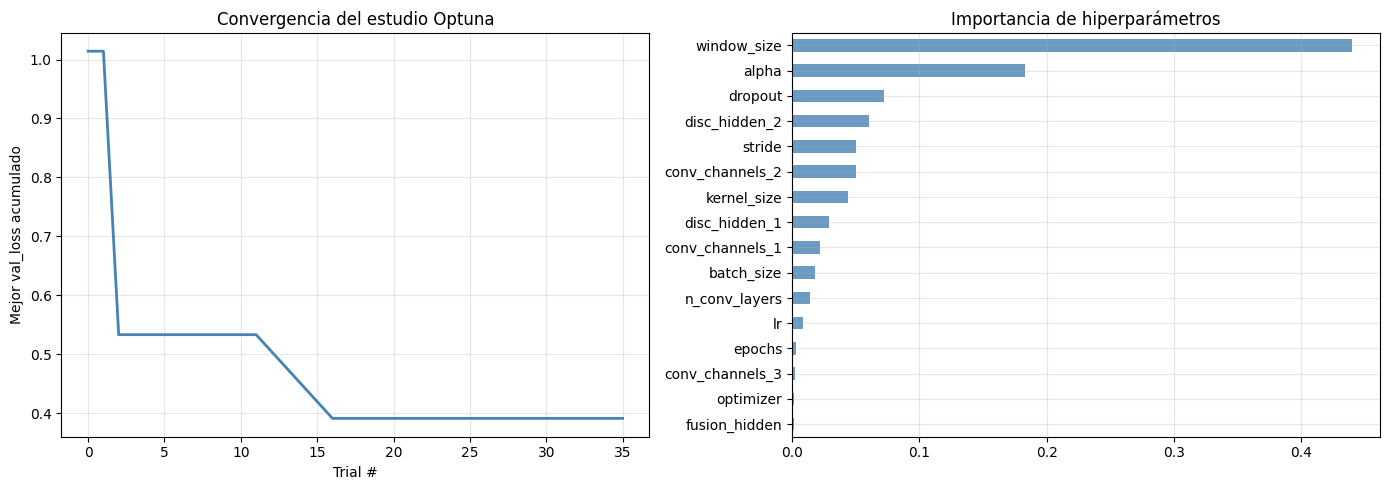

In [19]:
# Evolución del mejor valor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolución temporal
best_so_far = []
for t in sorted(study.trials, key=lambda x: x.number):
    if t.state == optuna.trial.TrialState.COMPLETE:
        current_best = min([s.value for s in study.trials
                            if s.state == optuna.trial.TrialState.COMPLETE
                            and s.number <= t.number])
        best_so_far.append((t.number, current_best))

if best_so_far:
    ns, vals = zip(*best_so_far)
    axes[0].plot(ns, vals, color="steelblue", linewidth=2)
    axes[0].set_xlabel("Trial #"); axes[0].set_ylabel("Mejor val_loss acumulado")
    axes[0].set_title("Convergencia del estudio Optuna"); axes[0].grid(True, alpha=0.3)

# Importancia de hiperparámetros
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.Series(importances).sort_values(ascending=True)
    imp_df.plot(kind="barh", ax=axes[1], color="steelblue", alpha=0.8)
    axes[1].set_title("Importancia de hiperparámetros"); axes[1].grid(True, alpha=0.3)
except Exception as e:
    axes[1].text(0.5, 0.5, f"No disponible:\n{e}", ha="center", va="center",
                 transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "optuna_convergence.png"), dpi=120, bbox_inches="tight")
plt.show()


## 12. Guardar configuración del mejor trial

In [20]:
best_params = study.best_trial.params
best_val    = study.best_trial.value

# Calcular disc_dim con los mejores hiperparámetros
_X_tr_c, _X_tr_d, _, _ = build_windows_from_df(
    df_train_sc, continuous_cols, discrete_cols,
    best_params["window_size"], best_params["stride"]
)
best_cont_channels = int(_X_tr_c.shape[1])
best_disc_dim      = int(_X_tr_d.shape[1])
del _X_tr_c, _X_tr_d

config = {
    "version":        "a12_optuna_v1",
    "dataset":        "SWaT A12 Mar 2026",
    "csv_path":       str(RAW_CSV),
    "warmup_seconds": WARMUP_SECONDS,
    "n_normal_rows":  len(df_work),
    "n_train":        len(df_train),
    "n_val":          len(df_val),
    "n_test":         len(df_test),
    "continuous_cols": continuous_cols,
    "discrete_cols":   discrete_cols,
    "feature_cols":    feature_cols,
    "cont_channels":   best_cont_channels,
    "disc_dim":        best_disc_dim,
    "disc_max":        disc_max.to_dict(),
    "best_val_loss":   float(best_val),
    "best_params":     best_params,
}

config_path = SAVE_DIR / "optuna_best_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

trials_df.to_csv(SAVE_DIR / "optuna_trials.csv", index=False)

print("✅ Configuración guardada en:", config_path)
print()
print("=" * 55)
print("MEJORES HIPERPARÁMETROS A12")
print("=" * 55)
print(f"val_loss:        {best_val:.6f}")
print(f"window_size:     {best_params['window_size']}")
print(f"stride:          {best_params['stride']}")
print(f"n_conv_layers:   {best_params['n_conv_layers']}")
print(f"conv_channels:   {best_params.get('conv_channels_1')}/{best_params.get('conv_channels_2')}/{best_params.get('conv_channels_3')}")
print(f"kernel_size:     {best_params['kernel_size']}")
print(f"disc_hidden:     {best_params['disc_hidden_1']}/{best_params['disc_hidden_2']}")
print(f"fusion_hidden:   {best_params['fusion_hidden']}")
print(f"dropout:         {best_params['dropout']:.3f}")
print(f"batch_size:      {best_params['batch_size']}")
print(f"lr:              {best_params['lr']:.2e}")
print(f"optimizer:       {best_params['optimizer']}")
print(f"alpha (cont/disc): {best_params['alpha']:.3f}")
print(f"epochs:          {best_params['epochs']}")
print()
print(f"cont_channels:   {best_cont_channels} | disc_dim: {best_disc_dim}")
print()
print("Siguiente paso: usar estos parámetros en 01b_conv1d_hybrid_a12_final.ipynb")


✅ Configuración guardada en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12\optuna_best_config.json

MEJORES HIPERPARÁMETROS A12
val_loss:        0.391588
window_size:     30
stride:          5
n_conv_layers:   1
conv_channels:   32/8/4
kernel_size:     5
disc_hidden:     64/32
fusion_hidden:   128
dropout:         0.186
batch_size:      64
lr:              8.62e-04
optimizer:       AdamW
alpha (cont/disc): 0.306
epochs:          40

cont_channels:   31 | disc_dim: 124

Siguiente paso: usar estos parámetros en 01b_conv1d_hybrid_a12_final.ipynb


## 13. Verificación rápida del mejor modelo

Se entrena el mejor modelo con todos los epochs y se visualiza la curva de entrenamiento.


Train: (3069, 31, 30) | Val: (1019, 31, 30) | Test: (1019, 31, 30)
Epoch  10/50 | Train: 0.07202 | Val: 1.13431
Epoch  20/50 | Train: 0.05421 | Val: 0.82310
Epoch  30/50 | Train: 0.04812 | Val: 0.44856
Epoch  40/50 | Train: 0.04157 | Val: 0.41177
Epoch  50/50 | Train: 0.03929 | Val: 0.48691


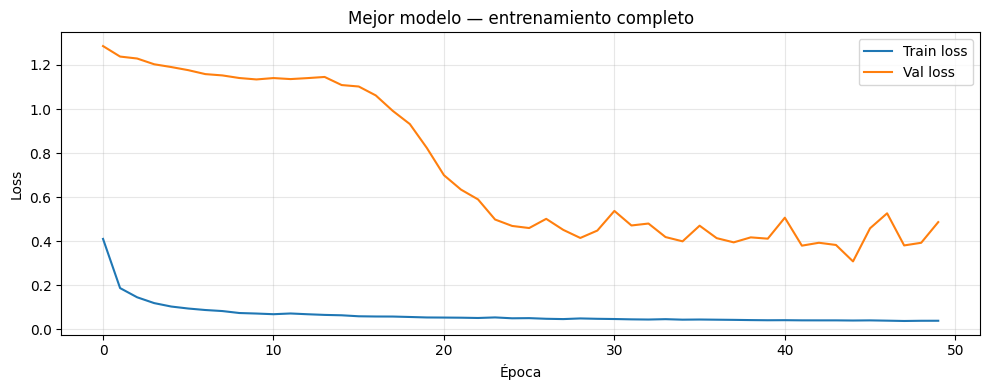


Train loss final: 0.039292
Val   loss final: 0.486911


In [21]:
# Construir ventanas con los mejores hiperparámetros
bp = best_params
X_tr_c, X_tr_d, _, _ = build_windows_from_df(
    df_train_sc, continuous_cols, discrete_cols, bp["window_size"], bp["stride"])
X_va_c, X_va_d, _, _ = build_windows_from_df(
    df_val_sc,   continuous_cols, discrete_cols, bp["window_size"], bp["stride"])
X_te_c, X_te_d, _, _ = build_windows_from_df(
    df_test_sc,  continuous_cols, discrete_cols, bp["window_size"], bp["stride"])

print(f"Train: {X_tr_c.shape} | Val: {X_va_c.shape} | Test: {X_te_c.shape}")

train_loader_b = DataLoader(
    TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                  torch.tensor(X_tr_d, dtype=torch.float32)),
    batch_size=bp["batch_size"], shuffle=True, drop_last=True
)
val_loader_b = DataLoader(
    TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                  torch.tensor(X_va_d, dtype=torch.float32)),
    batch_size=bp["batch_size"], shuffle=False
)

torch.manual_seed(SEED)
best_model = HybridConv1DAutoencoder(
    cont_channels=X_tr_c.shape[1], seq_len=bp["window_size"],
    disc_dim=X_tr_d.shape[1],
    n_conv_layers=bp["n_conv_layers"],
    conv_channels_1=bp["conv_channels_1"],
    conv_channels_2=bp["conv_channels_2"],
    conv_channels_3=bp["conv_channels_3"],
    kernel_size=bp["kernel_size"],
    disc_hidden_1=bp["disc_hidden_1"],
    disc_hidden_2=bp["disc_hidden_2"],
    fusion_hidden=bp["fusion_hidden"],
    dropout=bp["dropout"]
).to(device)

opt_cls = torch.optim.Adam if bp["optimizer"] == "Adam" else torch.optim.AdamW
opt_b   = opt_cls(best_model.parameters(), lr=bp["lr"])

FINAL_EPOCHS = 50   # más épocas para el modelo final
train_hist, val_hist = [], []

best_model.train()
for epoch in range(FINAL_EPOCHS):
    tl = 0.0
    best_model.train()
    for x_c, x_d in train_loader_b:
        x_c, x_d = x_c.to(device), x_d.to(device)
        opt_b.zero_grad()
        xc_hat, xd_hat = best_model(x_c, x_d)
        loss = hybrid_criterion(x_c, xc_hat, x_d, xd_hat, bp["alpha"])
        loss.backward(); opt_b.step(); tl += loss.item()
    tl /= len(train_loader_b)

    best_model.eval()
    vl = 0.0
    with torch.no_grad():
        for x_c, x_d in val_loader_b:
            x_c, x_d = x_c.to(device), x_d.to(device)
            xc_hat, xd_hat = best_model(x_c, x_d)
            vl += hybrid_criterion(x_c, xc_hat, x_d, xd_hat, bp["alpha"]).item()
    vl /= len(val_loader_b)
    train_hist.append(tl); val_hist.append(vl)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{FINAL_EPOCHS} | Train: {tl:.5f} | Val: {vl:.5f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_hist, label="Train loss"); ax.plot(val_hist, label="Val loss")
ax.set_xlabel("Época"); ax.set_ylabel("Loss"); ax.set_title("Mejor modelo — entrenamiento completo")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "best_model_training_curve.png"), dpi=120, bbox_inches="tight")
plt.show()

print(f"\nTrain loss final: {train_hist[-1]:.6f}")
print(f"Val   loss final: {val_hist[-1]:.6f}")


In [22]:
# Guardar modelo entrenado
torch.save(best_model.state_dict(), SAVE_DIR / "model_state_optuna_best.pt")
print("✅ Modelo guardado:", SAVE_DIR / "model_state_optuna_best.pt")
print()
print("Archivos generados en", SAVE_DIR, ":")
for f in sorted(SAVE_DIR.iterdir()):
    print(f"  {f.name}")


✅ Modelo guardado: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12\model_state_optuna_best.pt

Archivos generados en d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12 :
  best_model_training_curve.png
  disc_max_dict.pkl
  model_state_optuna_best.pt
  optuna_best_config.json
  optuna_convergence.png
  optuna_trials.csv
  scaler_cont.pkl
